In [1]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import os
import re
import warnings

from itertools import cycle
from labellines import labelLines

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 12,
    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

EXPERIMENT_BASE='16-weight-perturbation'

# Beamer 16:9
WIDTH=455.24408

#WIDTH=441.01775
OUTPUT_DIR=f'../{EXPERIMENT_BASE}/images'

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT = 'png'

# Mapping of full model names to abbreviations
MODEL_NAME_MAP = {
    'vit_base_patch16_224.augreg_in21k': 'ViT',
    'resnetv2_50x1_bit.goog_in21k': 'ResNetV2',
}

N_BOOTSTRAP_SAMPLES=100

In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [3]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [4]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [5]:
def prepare_data(data):
    records = []
    for experiment_details in data:
        # Extracting values from the JSON structure
        subset_size = experiment_details['configuration']['subset_size']
        pretrained = experiment_details['configuration']['pretrained']
        weight_perturbation_level = experiment_details['configuration']['weight_perturbation_level']
        max_grad_norm = experiment_details['hyperparameters']['max_grad_norm']
        epochs = experiment_details['hyperparameters']['epochs']
                    
        learning_rate = experiment_details['best_params']['learning_rate']
        batch_size = experiment_details['best_params']['batch_size']

        # Handling the full batch size case
        if batch_size == -1:
            full_batch_size = 7500 if subset_size == 0.1 else 7500
            batch_size = full_batch_size

        record = {
            'runtime': experiment_details['runtime'],
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'subset_size': subset_size,
            'weight_perturbation_level': weight_perturbation_level,
            'epsilon': experiment_details['hyperparameters']['target_epsilon'],
            'max_grad_norm': max_grad_norm,
            'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'epochs': epochs,
            'pretrained': pretrained,
        }

        # Add final metrics also
        for metric_name, metric_value in experiment_details['final_metrics'].items():
            record[metric_name] = metric_value

        records.append(record)

    df = pd.DataFrame(records)

    df['runtime_seconds'] = pd.to_timedelta(df['runtime']).dt.total_seconds()

    return df


# Accuracy trends by noise level

In [6]:
def plot_accuracy_trends(prepared_data, output_dir=None, min_grad_norm=0):
    # Sort values
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'weight_perturbation_level', 'epochs', 'pretrained'], inplace=True)
    
    # Group by model, dataset, subset size, and epsilon
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'epochs'])

    for (model, dataset, subset, epsilon, epochs), group in groups:
        fig, ax = get_figure((1, 1), fraction=1.5)
        model_name = MODEL_NAME_MAP.get(model, model)

        # Group by weight_perturbation_level and pretrained status
        grouped_by_weight = group.groupby(['weight_perturbation_level', 'pretrained'])

        # Get the unique combinations of weight perturbation levels and pretrained status
        weight_levels = grouped_by_weight.groups.keys()
        
        # Map the levels to equally spaced regions for the colormap
        positions = np.linspace(0, 1, len(weight_levels))
        cmap = plt.cm.viridis

        for i, ((weight_perturbation_level, pretrained), weight_data) in enumerate(grouped_by_weight):
            # Set color based on position in colormap
            color = cmap(positions[i])
            weight_data = weight_data.sort_values(by='max_grad_norm')

            # Determine label based on pretrained status and weight perturbation level
            if not pretrained and weight_perturbation_level == 0:
                label = 'From scratch'
                color = 'black'
            else:
                label = f'Weight Perturbation {weight_perturbation_level:.3f}'

            grad_norm_grouped = weight_data.groupby('max_grad_norm')
            mean_accuracy = []
            grad_norms = []

            for grad_norm, grad_group in grad_norm_grouped:
                # Skip grad_norm values smaller than min grad norm
                if grad_norm < min_grad_norm:
                    continue

                mean_accuracy.append(grad_group['MulticlassAccuracy'].mean())
                grad_norms.append(grad_norm)

            # Plot accuracy for the current weight perturbation level or "From scratch"
            ax.plot(grad_norms, mean_accuracy, label=label, marker='o', linestyle='-', color=color)

        # Set title and labels
        ax.set_title(f'Accuracy Trends for {model_name} on {dataset.split("/")[-1]} ({int(subset*100)}\% Subset, $\epsilon={epsilon}$, {epochs} Epochs)')
        ax.set_xlabel('Clipping Bound')
        ax.set_ylabel('Accuracy')
        ax.set_xscale('log')

        # Set x-ticks and labels
        all_grad_norms = group['max_grad_norm'].unique()
        all_grad_norms = [gn for gn in all_grad_norms if gn >= min_grad_norm]
        all_grad_norms.sort()

        ax.set_xticks(all_grad_norms)
        ax.set_xticklabels([f'{x:.5f}' for x in all_grad_norms], rotation=45)

        # Add legend and grid
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.grid(True)

        # Save plot if output_dir is provided
        if output_dir:
            safe_dataset_name = dataset.split('/')[-1]
            plt.savefig(os.path.join(output_dir, f'accuracy_trends_{model_name}_{safe_dataset_name}_subset{subset}_epsilon{epsilon}_epochs{epochs}.{IMG_FORMAT}'), bbox_inches='tight')

        plt.show()

In [7]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    #plot_accuracy_trends(processed_data, output_dir=OUTPUT_DIR, min_grad_norm=1)
    plot_accuracy_trends(processed_data, output_dir=OUTPUT_DIR)

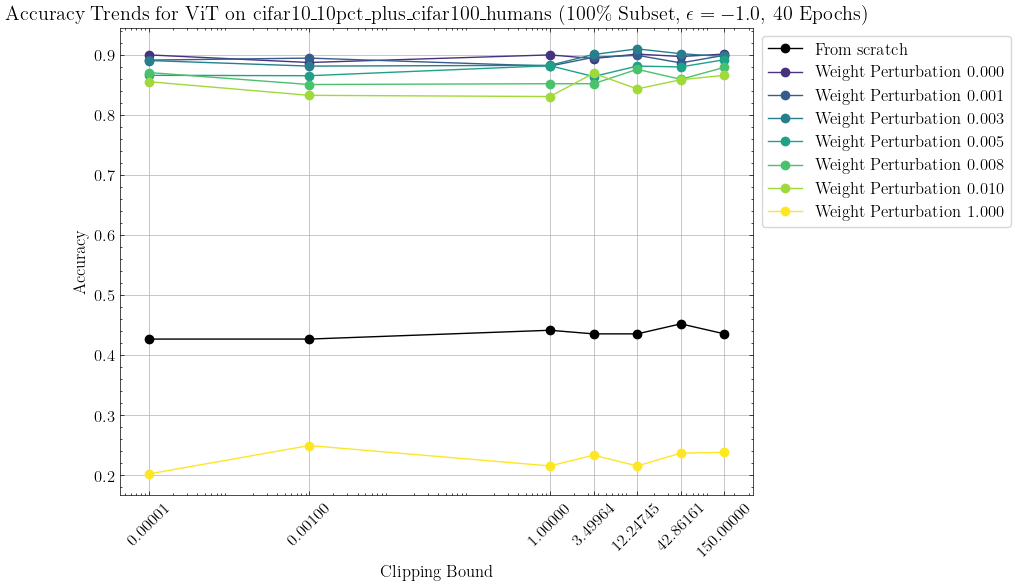

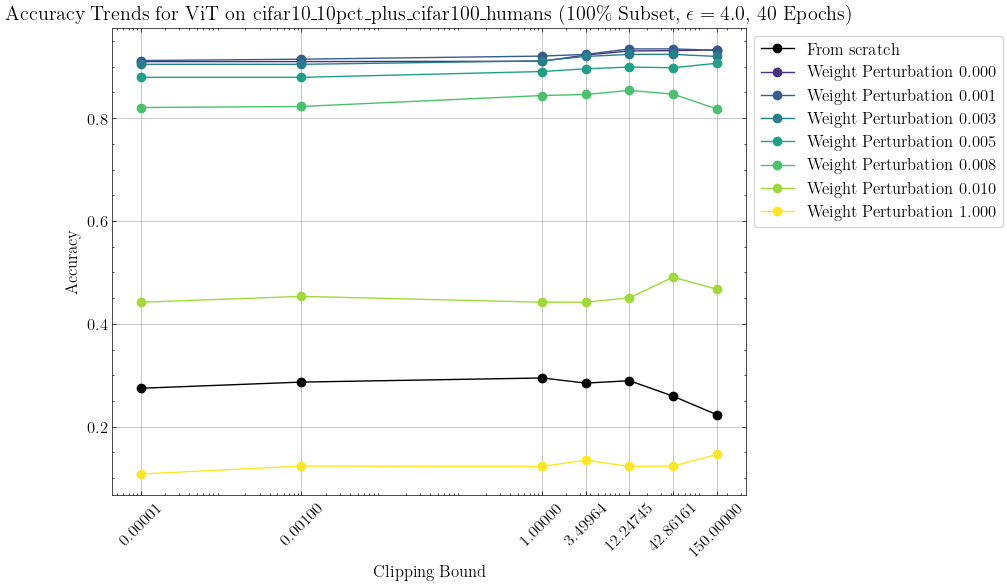

In [8]:
plot()

# Acccuracy trends by noise level - relative differences

In [9]:
def plot_accuracy_trends_relative_differences(prepared_data, output_dir=None, min_grad_norm=0, y_margin=0.1):
    # Sort values
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'weight_perturbation_level', 'max_grad_norm', 'epochs', 'pretrained'], inplace=True)
    
    # Group the data for plotting
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'epochs'])

    # Find the global maximum difference from the best accuracy
    global_max_difference = float('-inf')

    for (model, dataset, subset, epsilon, epochs), group in groups:
        grouped_by_weight = group.groupby(['weight_perturbation_level', 'pretrained'])

        for (weight_perturbation_level, pretrained), weight_data in grouped_by_weight:
            weight_data = weight_data.sort_values(by='max_grad_norm')

            grad_norm_grouped = weight_data.groupby('max_grad_norm')
            best_accuracy = float('-inf')

            # Find the best accuracy for this specific weight noise level
            for grad_norm, grad_group in grad_norm_grouped:
                if grad_norm < min_grad_norm:
                    continue

                accuracy = grad_group['MulticlassAccuracy'].mean()
                best_accuracy = max(best_accuracy, accuracy)

            # Now find the maximum difference for this curve
            for grad_norm, grad_group in grad_norm_grouped:
                if grad_norm < min_grad_norm:
                    continue

                accuracy = grad_group['MulticlassAccuracy'].mean()
                difference = best_accuracy - accuracy
                global_max_difference = max(global_max_difference, difference)

    # Plot each model, dataset, subset, and epsilon in separate plots
    for (model, dataset, subset, epsilon, epochs), group in groups:
        fig, ax = get_figure((1, 1), fraction=1.5)
        model_name = MODEL_NAME_MAP.get(model, model)

        # Group by weight noise level and pretrained status for plotting
        grouped_by_weight = group.groupby(['weight_perturbation_level', 'pretrained'])

        # Get the unique combinations of weight perturbation levels and pretrained status
        weight_levels = grouped_by_weight.groups.keys()

        # Map to the levels to equally space regions for the color map
        positions = np.linspace(0, 1, len(weight_levels))
        cmap = plt.cm.viridis

        for i, ((weight_perturbation_level, pretrained), weight_data) in enumerate(grouped_by_weight):
            color = cmap(positions[i])
            weight_data = weight_data.sort_values(by='max_grad_norm')

            # Determine label based on pretrained status and weight perturbation level
            if not pretrained and weight_perturbation_level == 0:
                label = 'From scratch'
                color = 'black'
            else:
                label = f'Weight noise {weight_perturbation_level:.3f}'

            grad_norm_grouped = weight_data.groupby('max_grad_norm')
            mean_accuracy = []
            grad_norms = []

            best_accuracy = float('-inf')

            # Find the best accuracy for this weight noise level
            for grad_norm, grad_group in grad_norm_grouped:
                if grad_norm < min_grad_norm:
                    continue

                accuracy = grad_group['MulticlassAccuracy'].mean()
                best_accuracy = max(best_accuracy, accuracy)

            # Plot the differences from the best accuracy
            for grad_norm, grad_group in grad_norm_grouped:
                if grad_norm < min_grad_norm:
                    continue

                accuracy = grad_group['MulticlassAccuracy'].mean()
                mean_accuracy.append(accuracy - best_accuracy)  # Difference from the best
                grad_norms.append(grad_norm)

            if grad_norms:
                ax.plot(grad_norms, mean_accuracy, label=label, marker='o', linestyle='-', color=color)

        ax.set_ylim([-global_max_difference, 0.001])

        ax.set_title(f'Difference to best for {model_name} on {dataset.split("/")[-1]} ({int(subset*100)}\% subset, $\epsilon={epsilon}$, {epochs} epochs)')
        
        ax.set_xlabel('Clipping bound')
        ax.set_ylabel('Difference to best accuracy')
        ax.set_xscale('log')

        # Set x-ticks and labels
        all_grad_norms = group['max_grad_norm'].unique()
        all_grad_norms = [gn for gn in all_grad_norms if gn >= min_grad_norm]
        all_grad_norms.sort()

        ax.set_xticks(all_grad_norms)
        ax.set_xticklabels([f'{x:.5f}' for x in all_grad_norms], rotation=45)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.grid(True)

        # Save plot if output_dir is provided
        if output_dir:
            clean_dataset_name = dataset.split('/')[-1]
            plt.savefig(os.path.join(output_dir, f'relative_accuracy_diff_{model_name}_{clean_dataset_name}_subset{subset}_epsilon{epsilon}_epochs{epochs}.{IMG_FORMAT}'), bbox_inches='tight')

        plt.show()

In [10]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    #plot_accuracy_trends_relative_differences(processed_data, output_dir=OUTPUT_DIR, min_grad_norm=1)
    plot_accuracy_trends_relative_differences(processed_data, output_dir=OUTPUT_DIR)

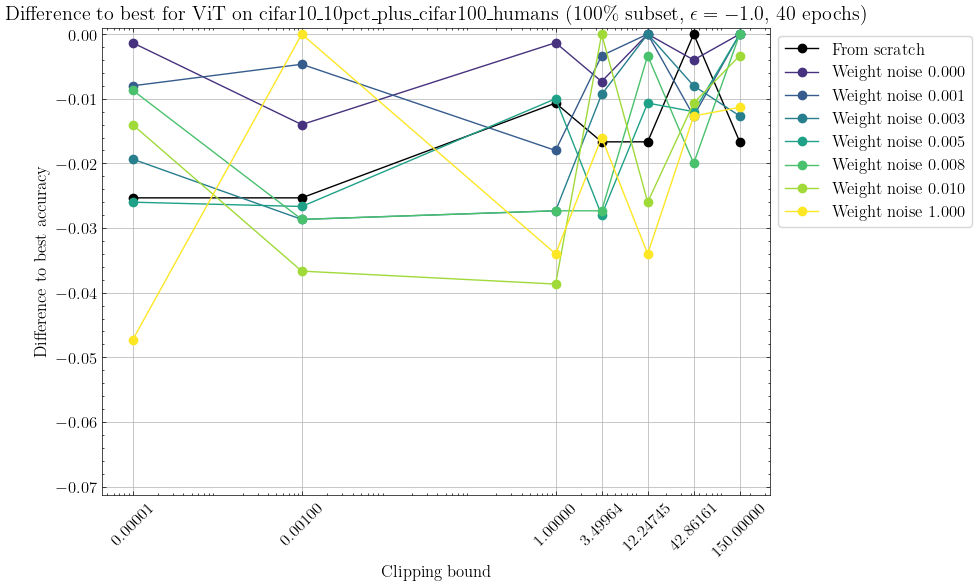

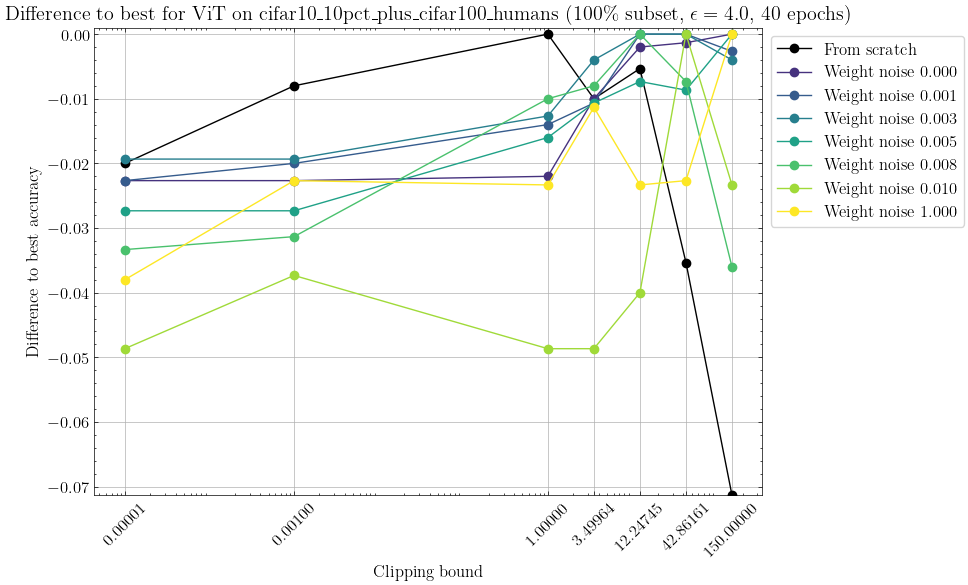

In [11]:
plot()